In [4]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import mglearn

## Univariate Statistics

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

# get deterministic random numbers
rng = np.random.RandomState(42)
noise = rng.normal(size=(len(cancer.data), 50))

# add noise featues to the data
# the first 30 features are from the dataset, the next 50 are noise
x_w_noise = np.hstack([cancer.data, noise])

x_train, x_test, y_train, y_test = train_test_split(
    x_w_noise, cancer.target, random_state=0, test_size=.5)

# use f_classif (the default) and SelectPercentile to select 50% of features
select = SelectPercentile(percentile=50)
select.fit(x_train, y_train)

# transform training set
x_train_selected = select.transform(x_train)

print('x_train.shape: {}'.format(x_train.shape))
print('x_train_selected.shaope: {}'.format(x_train_selected.shape))

x_train.shape: (284, 80)
x_train_selected.shaope: (284, 40)


[ True  True  True  True  True  True  True  True  True False  True False
  True  True  True  True  True  True False False  True  True  True  True
  True  True  True  True  True  True False False False  True False  True
 False False  True False False False False  True False False  True False
 False  True False  True False False False False False False  True False
  True False False False False  True False  True False False False False
  True  True False  True False False False False]


Text(0.5, 0, 'Sample index')

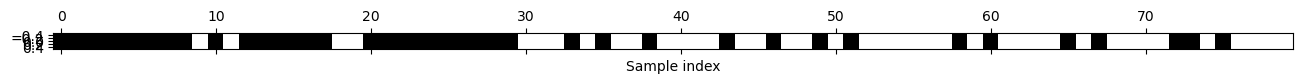

In [11]:
mask = select.get_support()
print(mask)

# visualize the mask -- black is True, white is False
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel('Sample index')

In [20]:
from sklearn.linear_model import LogisticRegression

# transform test data
x_test_selected = select.transform(x_test)

lr = LogisticRegression(max_iter=100000)
lr.fit(x_train, y_train)
print('Score with all features: {:.3f}'.format(lr.score(x_test, y_test)))
lr.fit(x_train_selected, y_train)
print('Score with only selected features: {:.3f}'.format(
    lr.score(x_test_selected, y_test)))

Score with all features: 0.947
Score with only selected features: 0.933


## Model-Based feature Selection

In [21]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
select = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    threshold='median')

In [22]:
select.fit(x_train, y_train)
x_train_l1 = select.transform(x_train)
print('x_train.shape: {}'.format(x_train.shape))
print('x_train_l1.shape: {}'.format(x_train_l1.shape))

x_train.shape: (284, 80)
x_train_l1.shape: (284, 40)


Text(0.5, 0, 'Sample index')

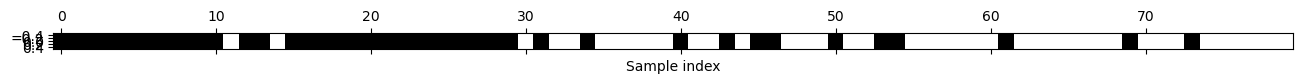

In [23]:
mask = select.get_support()

# visualize the mask -- black is True, white is False
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel('Sample index')

In [27]:
x_test_l1 = select.transform(x_test)
score = LogisticRegression().fit(x_train_l1, y_train).score(x_test_l1, y_test)
print('test score: {:.3f}'.format(score))

test score: 0.930


C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Iterative Feature Selection

Text(0.5, 0, 'Sample index')

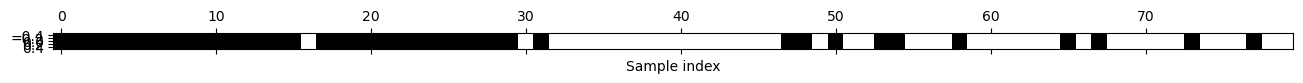

In [29]:
from sklearn.feature_selection import RFE
select = RFE(RandomForestClassifier(n_estimators=100, random_state=42),
            n_features_to_select=40)

select.fit(x_train, y_train)

# visualize the selected features:
mask = select.get_support()
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel('Sample index')

In [31]:
x_train_rfe = select.transform(x_train)
x_test_rfe = select.transform(x_test)

score = LogisticRegression().fit(x_train_rfe, y_train).score(x_test_rfe, y_test)
print('test score: {:.3f}'.format(score))

test score: 0.930


C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
print('test score: {:.3f}'.format(select.score(x_test, y_test)))

test score: 0.951


## Utilizing Expert Knowledge

In [7]:
citibike = mglearn.datasets.load_citibike()
print('Citi bike data:\n{}'.format(citibike.head()))

Citi bike data:
starttime
2015-08-01 00:00:00     3
2015-08-01 03:00:00     0
2015-08-01 06:00:00     9
2015-08-01 09:00:00    41
2015-08-01 12:00:00    39
Freq: 3H, Name: one, dtype: int64


C:\Users\Rio Agustian\AppData\Roaming\Python\Python310\site-packages\mglearn\datasets.py:57: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  data_resampled = data_starttime.resample("3h").sum().fillna(0)


Text(0, 0.5, 'Rentals')

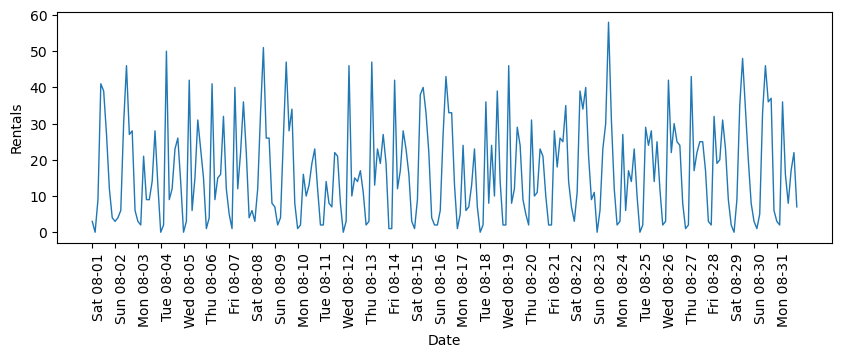

In [11]:
plt.figure(figsize=(10, 3))
xticks = pd.date_range(start=citibike.index.min(), end=citibike.index.max(),
                      freq='D')
plt.xticks(xticks, xticks.strftime('%a %m-%d'), rotation=90, ha='left')
plt.plot(citibike, linewidth=1)
plt.xlabel('Date')
plt.ylabel('Rentals')

In [20]:
# extract the target values (numbr of rentals)
y = citibike.values

# convert the time to POSIX time using'%s'
x = citibike.index.astype('int64').values.reshape(-1, 1) // 10**9

In [26]:
# use the first 184 data points for training, and the rest for testing
n_train = 184

# function to evaluate and plot a regressor on a given feature set
def eval_on_features(features, target, regressor):
    # split the given features into a training and a test set
    x_train, x_test = features[:n_train], features[n_train:]
    # also split the target array
    y_train, y_test = target[:n_train], target[n_train:]
    regressor.fit(x_train, y_train)
    print('Test-set R^2: {:.2f}'.format(regressor.score(x_test, y_test)))
    y_pred = regressor.predict(x_test)
    y_pred_train = regressor.predict(x_train)
    plt.figure(figsize=(10, 3))
    
    plt.xticks(range(0, len(x), 8), xticks.strftime('%a %m-$d'), rotation=90,
              ha='left')
    
    plt.plot(range(n_train), y_train, label='train')
    plt.plot(range(n_train, len(y_test) + n_train), y_test, '-', label='test')
    plt.plot(range(n_train), y_pred_train, '--', label='prediction train')
    
    plt.plot(range(n_train, len(y_test) + n_train), y_pred, '--',
            label='prediction test')
    plt.legend(loc=(1.01, 0))
    plt.xlabel('Date')
    plt.ylabel('Rentals')

Test-set R^2: -0.04


<Figure size 640x480 with 0 Axes>

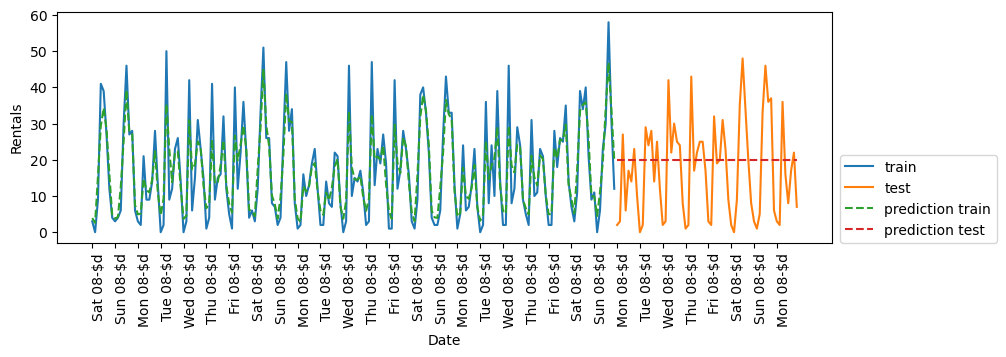

In [27]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100, random_state=0)
plt.figure()
eval_on_features(x, y, regressor)

Test-set R^2: 0.60


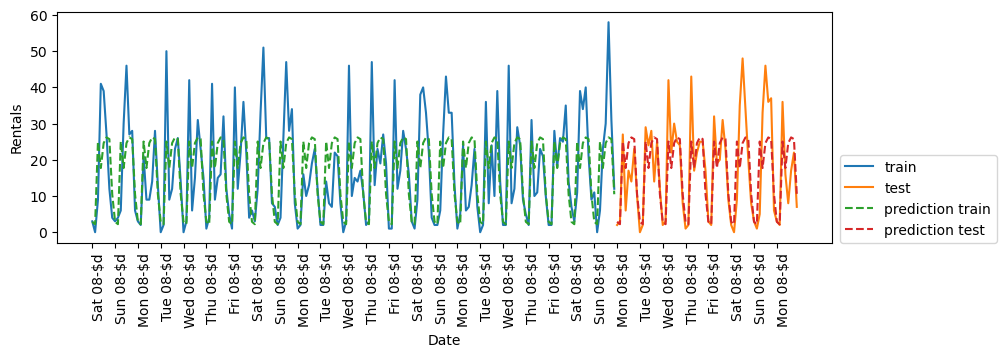

In [31]:
x_hour = citibike.index.hour.values.reshape(-1, 1)
eval_on_features(x_hour, y, regressor)

Test-set R^2: 0.84


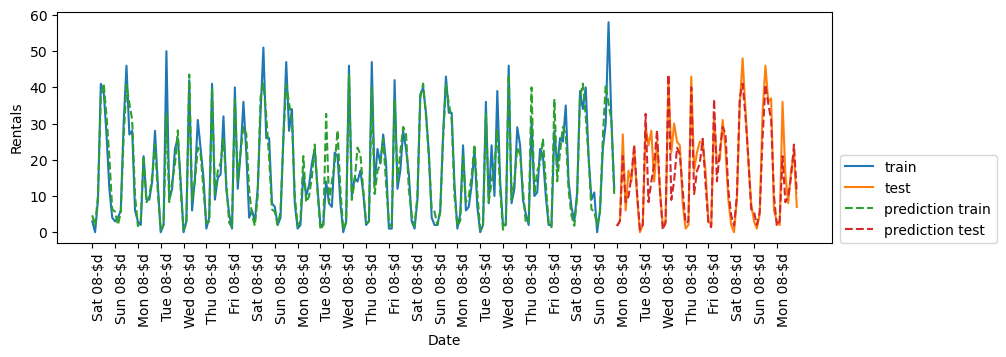

In [32]:
x_hour_week = np.hstack([citibike.index.dayofweek.values.reshape(-1, 1),
                        citibike.index.hour.values.reshape(-1, 1)])
eval_on_features(x_hour_week, y, regressor)

Test-set R^2: 0.13


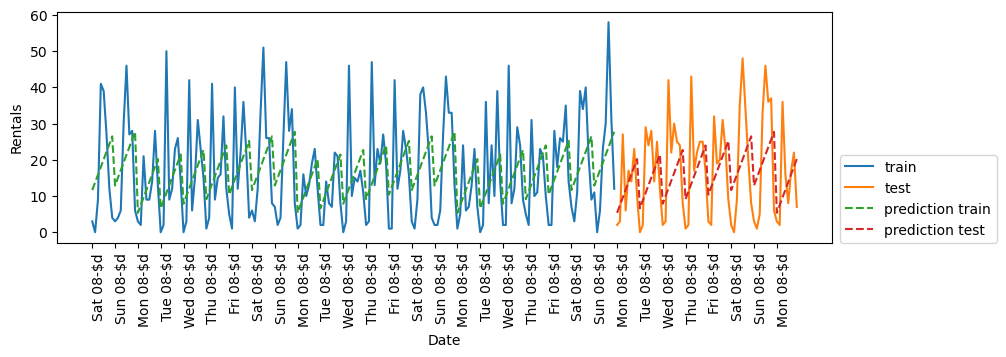

In [37]:
from sklearn.linear_model import LinearRegression, Ridge
eval_on_features(x_hour_week, y, LinearRegression())

Test-set R^2: 0.62


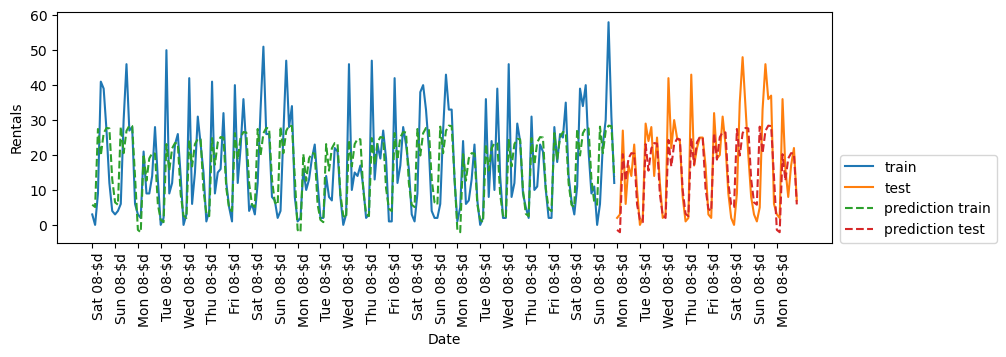

In [40]:
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures

enc = OneHotEncoder()
x_hour_week_onehot = enc.fit_transform(x_hour_week).toarray()
eval_on_features(x_hour_week_onehot, y, Ridge())

Test-set R^2: 0.85


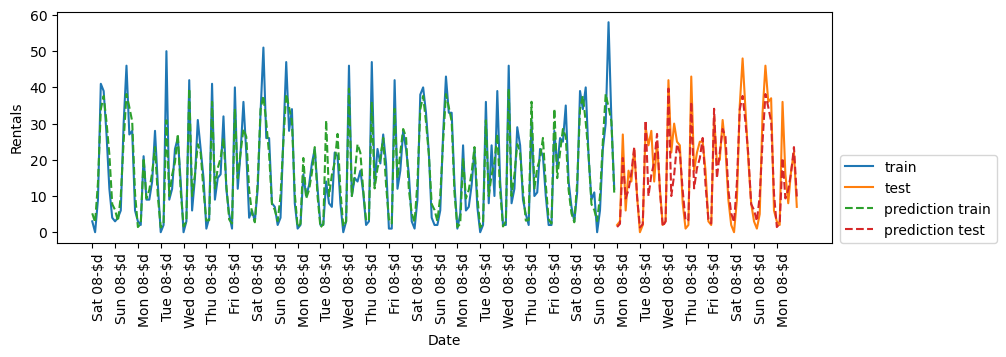

In [42]:
poly_transformer = PolynomialFeatures(degree=2, interaction_only=True,
                                     include_bias=False)
x_hour_week_onehot_poly = poly_transformer.fit_transform(x_hour_week_onehot)
lr = Ridge()
eval_on_features(x_hour_week_onehot_poly, y, lr)

Text(0, 0.5, 'Feature')

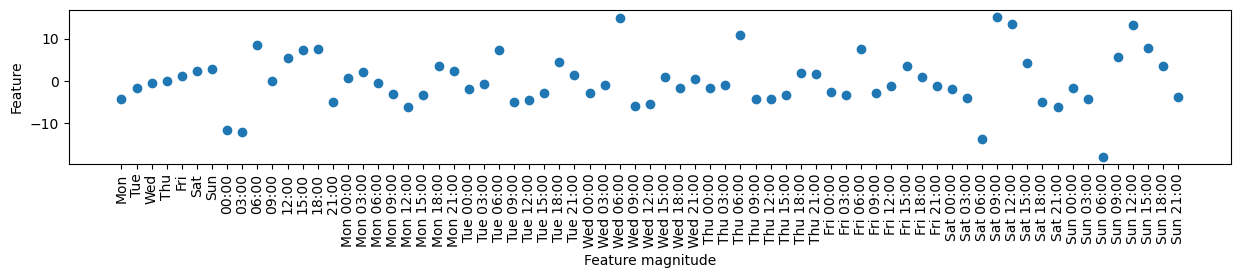

In [45]:
hour = ['%02d:00' % i for i in range(0, 23, 3)]
day  = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
features = day + hour

features_poly = poly_transformer.get_feature_names_out(features)
features_nonzero = np.array(features_poly)[lr.coef_ !=0]
coef_nonzero = lr.coef_[lr.coef_ !=0]

plt.figure(figsize=(15, 2))
plt.plot(coef_nonzero, 'o')
plt.xticks(np.arange(len(coef_nonzero)), features_nonzero, rotation=90)
plt.xlabel('Feature magnitude')
plt.ylabel('Feature')